In [5]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
# Upload the dataset ZIP file manually

uploaded = files.upload()

print("File uploaded successfully!")
print("Uploaded file:", list(uploaded.keys())[0])

Saving archive (1).zip to archive (1) (1).zip
File uploaded successfully!
Uploaded file: archive (1) (1).zip


In [7]:
# Extract the ZIP file

import zipfile
import os

zip_filename = list(uploaded.keys())[0]

extract_folder = "/content/house_dataset"

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [8]:
# Find the CSV file automatically inside the extracted folder

csv_file = None

for root, directories, files_list in os.walk(extract_folder):
    for file in files_list:
        if file.lower().endswith(".csv"):
            csv_file = os.path.join(root, file)
            break

    if csv_file is not None:
        break

if csv_file is None:
    print("CSV file was not found.")
else:
    print("CSV file found:", csv_file)

    df = pd.read_csv(csv_file)

    print("\nDataset loaded successfully!")
    print("Dataset shape:", df.shape)

    display(df.head())

CSV file found: /content/house_dataset/House Price Prediction Dataset.csv

Dataset loaded successfully!
Dataset shape: (2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [9]:
# Display information about the dataset

print("Dataset Information:")
print("--------------------")

df.info()

Dataset Information:
--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [10]:
# Check for missing values

print("Missing values in each column:")
print("--------------------------------")

print(df.isnull().sum())

Missing values in each column:
--------------------------------
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [11]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
# Display statistical summary of numerical columns

print("Statistical Summary:")
print("--------------------")

display(df.describe())

Statistical Summary:
--------------------


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [13]:
# Display all column names

print("Columns in the dataset:")
print("-----------------------")

for column in df.columns:
    print(column)

Columns in the dataset:
-----------------------
Id
Area
Bedrooms
Bathrooms
Floors
YearBuilt
Location
Condition
Garage
Price


In [15]:
# Display unique values of categorical columns

print("Unique Location values:")
print(df["Location"].unique())

print("\nUnique Condition values:")
print(df["Condition"].unique())

print("\nUnique Garage values:")
print(df["Garage"].unique())

Unique Location values:
['Downtown' 'Suburban' 'Urban' 'Rural']

Unique Condition values:
['Excellent' 'Good' 'Fair' 'Poor']

Unique Garage values:
['No' 'Yes']


In [16]:
# Separate input features and target variable

# Id is removed because it is only an identification number
X = df.drop(columns=["Id", "Price"])

# Price is the target variable
y = df["Price"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("Price")

Input Features:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage']

Target Variable:
Price


In [17]:
# Identify numerical and categorical features

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

Categorical Features:
['Location', 'Condition', 'Garage']


In [18]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1600, 8)
Testing data shape: (400, 8)


In [19]:
# Preprocess categorical features using One-Hot Encoding

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            "passthrough",
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing setup completed successfully!")

Preprocessing setup completed successfully!


In [20]:
# Create Linear Regression model pipeline

linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

print("Linear Regression model created successfully!")

Linear Regression model created successfully!


In [21]:
# Train the Linear Regression model

linear_regression_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [22]:
# Make predictions using the trained model

y_pred = linear_regression_model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 predicted prices:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predicted prices:
[521988.22189839 549119.31196651 487101.22235594 539752.7439933
 553242.24872512 521375.92025826 523320.18080583 578133.64353335
 545899.64738458 577368.69940644]


In [23]:
# Compare actual and predicted house prices

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("Actual vs Predicted House Prices:")
display(comparison.head(10))

Actual vs Predicted House Prices:


,Actual Price,Predicted Price
0,514764,521988.221898
1,694256,549119.311967
2,66375,487101.222356
3,650243,539752.743993
4,223285,553242.248725
5,468127,521375.920258
6,513002,523320.180806
7,911525,578133.643533
8,723265,545899.647385
9,339416,577368.699406


In [24]:
# Calculate regression performance metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("==============================")
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)
print("R² Score :", r2)

Linear Regression Performance
MAE      : 243241.97758826384
MSE      : 78321466146.0328
RMSE     : 279859.72583784326
R² Score : -0.006717808430749761


In [25]:
# Create a performance evaluation table

performance_table = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

display(performance_table)

,Metric,Value
0,MAE,2.432420e+05
1,MSE,7.832147e+10
2,RMSE,2.798597e+05
3,R² Score,-6.717808e-03


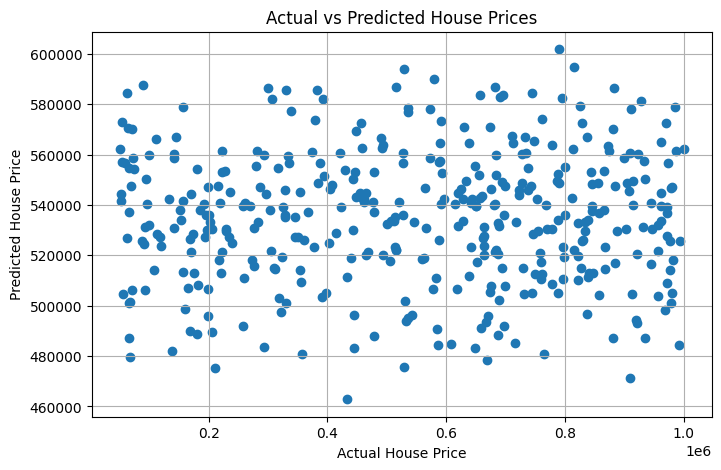

In [26]:
# Plot Actual vs Predicted House Prices

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)
plt.show()

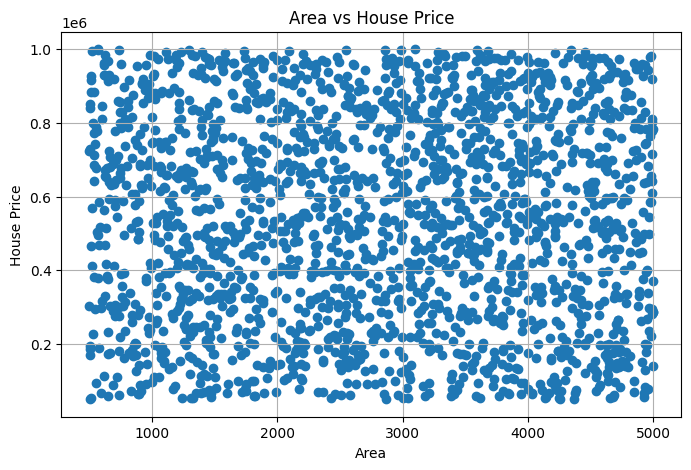

In [27]:
# Plot Area vs House Price

plt.figure(figsize=(8, 5))

plt.scatter(df["Area"], df["Price"])

plt.xlabel("Area")
plt.ylabel("House Price")
plt.title("Area vs House Price")

plt.grid(True)
plt.show()

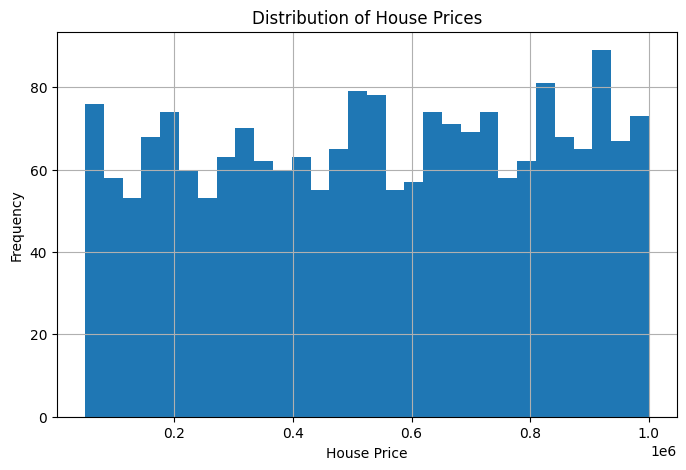

In [28]:
# Plot distribution of house prices

plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=30)

plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")

plt.grid(True)
plt.show()

In [29]:
# Select Area as input and Price as target for Gradient Descent

X_gd = df["Area"].values.astype(float)

y_gd = df["Price"].values.astype(float)

print("Input Feature : Area")
print("Target Variable : Price")
print("Number of samples:", len(X_gd))

Input Feature : Area
Target Variable : Price
Number of samples: 2000


In [30]:
# Standardize the Area values

X_mean = X_gd.mean()

X_std = X_gd.std()

X_scaled = (X_gd - X_mean) / X_std

print("Mean of Area:", X_mean)

print("Standard Deviation of Area:", X_std)

Mean of Area: 2786.2095
Standard Deviation of Area: 1294.8229715330779


In [31]:
# Initialize Gradient Descent parameters

m = 0.0
c = 0.0

learning_rate = 0.01

epochs = 1000

n = len(X_scaled)

cost_history = []

print("Initial Slope:", m)
print("Initial Intercept:", c)
print("Learning Rate:", learning_rate)
print("Number of Iterations:", epochs)

Initial Slope: 0.0
Initial Intercept: 0.0
Learning Rate: 0.01
Number of Iterations: 1000


In [32]:
# Implement Gradient Descent for Linear Regression

for i in range(epochs):

    # Calculate predicted values
    y_pred_gd = m * X_scaled + c

    # Calculate error
    error = y_pred_gd - y_gd

    # Calculate gradients
    dm = (2 / n) * np.sum(X_scaled * error)

    dc = (2 / n) * np.sum(error)

    # Update slope and intercept
    m = m - learning_rate * dm

    c = c - learning_rate * dc

    # Calculate Mean Squared Error cost
    cost = np.mean(error ** 2)

    # Store cost
    cost_history.append(cost)

print("Gradient Descent completed successfully!")

print("\nFinal Slope:", m)
print("Final Intercept:", c)
print("Final Cost:", cost_history[-1])

Gradient Descent completed successfully!

Final Slope: 426.1799555466843
Final Intercept: 537676.8540951074
Final Cost: 76374518662.88785


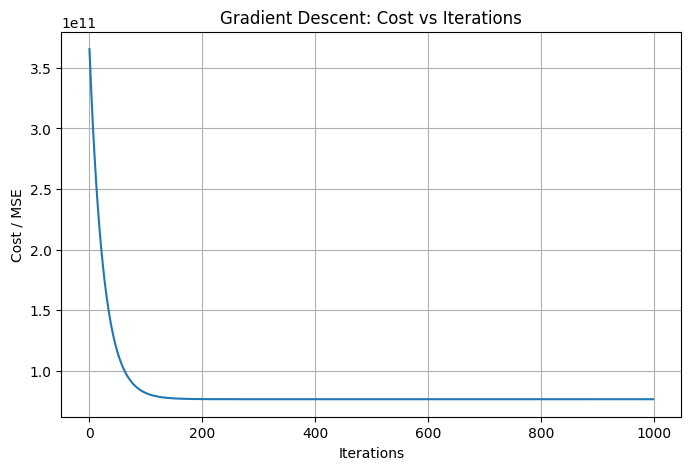

In [33]:
# Plot Cost vs Iterations

plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost / MSE")
plt.title("Gradient Descent: Cost vs Iterations")

plt.grid(True)
plt.show()

In [34]:
# Generate final predictions using Gradient Descent

gd_predictions = m * X_scaled + c

print("First 10 Gradient Descent predictions:")
print(gd_predictions[:10])


First 10 Gradient Descent predictions:
[537207.42938248 538165.88938654 537942.0731768  537077.74763743
 538381.14791767 538057.93097949 537968.07535411 537885.13169991
 536967.1560985  537478.97110754]


In [35]:
# Calculate Gradient Descent performance metrics

gd_mae = mean_absolute_error(
    y_gd,
    gd_predictions
)

gd_mse = mean_squared_error(
    y_gd,
    gd_predictions
)

gd_rmse = np.sqrt(gd_mse)

gd_r2 = r2_score(
    y_gd,
    gd_predictions
)

print("Gradient Descent Performance")
print("============================")
print("MAE      :", gd_mae)
print("MSE      :", gd_mse)
print("RMSE     :", gd_rmse)
print("R² Score :", gd_r2)

Gradient Descent Performance
MAE      : 239049.26012014714
MSE      : 76374518662.88788
RMSE     : 276359.4012565664
R² Score : 2.3781350944052093e-06


In [36]:
# Create Gradient Descent performance table

gd_performance = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        gd_mae,
        gd_mse,
        gd_rmse,
        gd_r2
    ]
})

display(gd_performance)

,Metric,Value
0,MAE,2.390493e+05
1,MSE,7.637452e+10
2,RMSE,2.763594e+05
3,R² Score,2.378135e-06


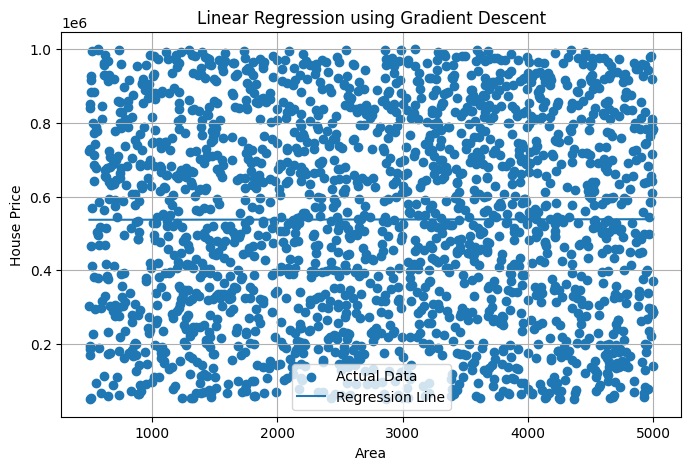

In [37]:
# Plot the regression line obtained using Gradient Descent

plt.figure(figsize=(8, 5))

plt.scatter(
    X_gd,
    y_gd,
    label="Actual Data"
)

sort_index = np.argsort(X_gd)

plt.plot(
    X_gd[sort_index],
    gd_predictions[sort_index],
    label="Regression Line"
)

plt.xlabel("Area")
plt.ylabel("House Price")

plt.title("Linear Regression using Gradient Descent")

plt.legend()

plt.grid(True)

plt.show()